In [ ]:
# Cell 1 - Mount Drive and install libraries
from google.colab import drive

try:
    drive.mount('/content/drive')
    print('✅ Drive mounted!')
except:
    print('✅ Drive already mounted!')

!pip install lime shap transformers torch -q

print('✅ Libraries installed!')

Mounted at /content/drive
✅ Drive mounted!
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 18.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
✅ Libraries installed!


In [ ]:
# Cell 2 - Import libraries and load model
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

from transformers import DistilBertForSequenceClassification, DistilBertTokenizer
from lime.lime_text import LimeTextExplainer

# Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️ Device: {device}')

# Load model
model = DistilBertForSequenceClassification.from_pretrained(
    '/content/drive/MyDrive/PhishingDetector/models/bert_model'
)
model = model.to(device)
model.eval()

# Load tokenizer
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

print('✅ Model and tokenizer loaded!')

🖥️ Device: cuda


Loading weights:   0%|          | 0/104 [00:01<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Model and tokenizer loaded!


In [ ]:
# Cell 3 - Load test data
base = '/content/drive/MyDrive/PhishingDetector/data/processed'

X_test = pd.read_csv(f'{base}/X_test.csv').squeeze()
y_test = pd.read_csv(f'{base}/y_test.csv').squeeze()

print(f'✅ Test data loaded!')
print(f'📊 Test samples: {len(X_test)}')

# Show some samples
print(f'\n🔍 Sample phishing email (cleaned):')
phishing_idx = y_test[y_test==1].index[0]
print(X_test[phishing_idx][:200])

print(f'\n🔍 Sample legit email (cleaned):')
legit_idx = y_test[y_test==0].index[0]
print(X_test[legit_idx][:200])

✅ Test data loaded!
📊 Test samples: 15908

🔍 Sample phishing email (cleaned):
elegant accessory sale friend appreciate care give classy gift

🔍 Sample legit email (cleaned):
interview schedule brent trefz attached please find interview packet referenced person including resume interview happen monday july please print three document hard copy question conflict schedule pl


In [ ]:
# Cell 4 - Prediction function for LIME
def predict_proba(texts):
    probabilities = []

    for text in texts:
        encoding = tokenizer(
            str(text),
            max_length=512,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        input_ids = encoding['input_ids'].to(device)
        attention_mask = encoding['attention_mask'].to(device)

        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probs = torch.softmax(outputs.logits, dim=1)
            probabilities.append(probs.cpu().numpy()[0])

    return np.array(probabilities)

# Test function
test_text = X_test.iloc[0]
probs = predict_proba([test_text])
print(f'✅ Prediction function ready!')
print(f'🔍 Sample prediction:')
print(f'   Legitimate probability: {probs[0][0]:.4f}')
print(f'   Phishing probability:   {probs[0][1]:.4f}')
print(f'   Prediction: {"Phishing" if probs[0][1] > 0.5 else "Legitimate"}')
print(f'   Actual:     {"Phishing" if y_test.iloc[0] == 1 else "Legitimate"}')

✅ Prediction function ready!
🔍 Sample prediction:
   Legitimate probability: 0.0004
   Phishing probability:   0.9996
   Prediction: Phishing
   Actual:     Phishing


In [ ]:
# Cell 5 - LIME explanation on phishing email
from lime.lime_text import LimeTextExplainer

explainer = LimeTextExplainer(class_names=['Legitimate', 'Phishing'])

# Pick a phishing email sample
phishing_sample = X_test[y_test[y_test==1].index[0]]
print(f'📧 Email being explained:')
print(phishing_sample[:300])
print(f'\nActual label: Phishing')

# Generate LIME explanation
print('\nGenerating LIME explanation... takes ~30 seconds...')
exp = explainer.explain_instance(
    phishing_sample,
    predict_proba,
    num_features=10,
    num_samples=100
)

# Print word contributions
print('\n📊 Top words contributing to PHISHING prediction:')
for word, weight in exp.as_list():
    direction = '🔴 Phishing' if weight > 0 else '🔵 Legit'
    print(f'   {direction} | {word:20s} | weight: {weight:.4f}')

📧 Email being explained:
elegant accessory sale friend appreciate care give classy gift

Actual label: Phishing

Generating LIME explanation... takes ~30 seconds...

📊 Top words contributing to PHISHING prediction:
   🔴 Phishing | classy               | weight: 0.0139
   🔴 Phishing | accessory            | weight: 0.0105
   🔴 Phishing | give                 | weight: 0.0087
   🔴 Phishing | elegant              | weight: 0.0087
   🔴 Phishing | gift                 | weight: 0.0082
   🔵 Legit | sale                 | weight: -0.0074
   🔴 Phishing | friend               | weight: 0.0074
   🔴 Phishing | care                 | weight: 0.0047
   🔵 Legit | appreciate           | weight: -0.0035


In [ ]:
# Cell 6 - LIME explanation on legitimate email
legit_sample = X_test[y_test[y_test==0].index[0]]
print(f'📧 Email being explained:')
print(legit_sample[:300])
print(f'\nActual label: Legitimate')

print('\nGenerating LIME explanation... takes ~30 seconds...')
exp_legit = explainer.explain_instance(
    legit_sample,
    predict_proba,
    num_features=10,
    num_samples=100
)

print('\n📊 Top words contributing to LEGITIMATE prediction:')
for word, weight in exp_legit.as_list():
    direction = '🔴 Phishing' if weight > 0 else '🔵 Legit'
    print(f'   {direction} | {word:20s} | weight: {weight:.4f}')

📧 Email being explained:
interview schedule brent trefz attached please find interview packet referenced person including resume interview happen monday july please print three document hard copy question conflict schedule please hesitate contact

Actual label: Legitimate

Generating LIME explanation... takes ~30 seconds...

📊 Top words contributing to LEGITIMATE prediction:
   🔴 Phishing | document             | weight: 0.0807
   🔵 Legit | attached             | weight: -0.0629
   🔴 Phishing | hard                 | weight: 0.0555
   🔵 Legit | please               | weight: -0.0552
   🔵 Legit | happen               | weight: -0.0543
   🔵 Legit | brent                | weight: -0.0523
   🔵 Legit | schedule             | weight: -0.0478
   🔵 Legit | three                | weight: -0.0476
   🔵 Legit | interview            | weight: -0.0353
   🔴 Phishing | contact              | weight: 0.0181


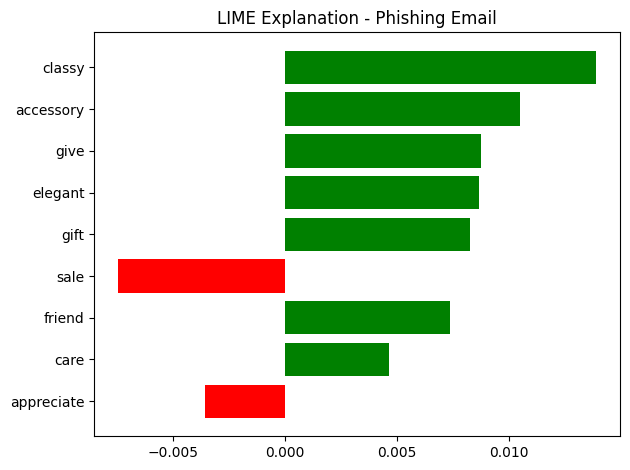

✅ Phishing LIME plot saved!


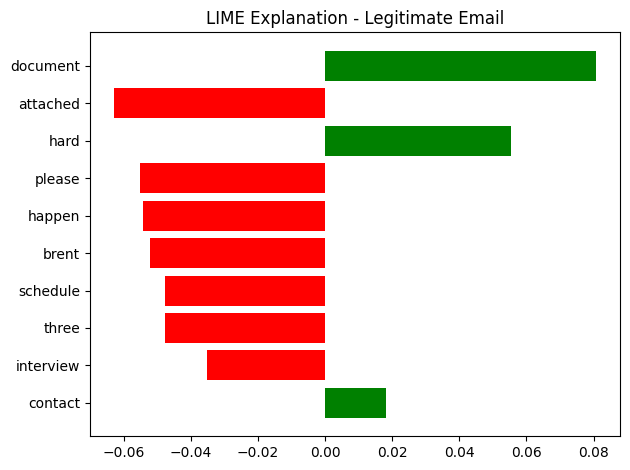

✅ Legit LIME plot saved!


In [ ]:
# Cell 7 - Save LIME visualizations
import os

os.makedirs('/content/drive/MyDrive/PhishingDetector/plots', exist_ok=True)

# Plot phishing explanation
fig1 = exp.as_pyplot_figure()
plt.title('LIME Explanation - Phishing Email')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PhishingDetector/plots/lime_phishing.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Phishing LIME plot saved!')

# Plot legit explanation
fig2 = exp_legit.as_pyplot_figure()
plt.title('LIME Explanation - Legitimate Email')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PhishingDetector/plots/lime_legit.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Legit LIME plot saved!')

In [ ]:
# Cell 8 - SHAP explanation
import shap

# Create prediction function for SHAP
def shap_predict(texts):
    return predict_proba(list(texts))

# Use small sample for SHAP (it's slower than LIME)
sample_texts = X_test.iloc[:20].tolist()

print('Generating SHAP explanations... takes 1-2 minutes...')

explainer_shap = shap.Explainer(
    shap_predict,
    masker=shap.maskers.Text(tokenizer=r'\W+'),
    output_names=['Legitimate', 'Phishing']
)

shap_values = explainer_shap(sample_texts[:5])

print('✅ SHAP values generated!')
print(f'📊 Shape: {shap_values.shape}')

Generating SHAP explanations... takes 1-2 minutes...


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  40%|████      | 2/5 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  80%|████████  | 4/5 [00:22<00:04,  4.66s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 5/5 [00:30<00:00,  5.81s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 6it [00:39,  9.92s/it]

✅ SHAP values generated!
📊 Shape: (5, None, 2)


📊 SHAP explanation for sample emails:

Sample 1 — Actual: Phishing



Sample 2 — Actual: Legitimate



Sample 3 — Actual: Phishing


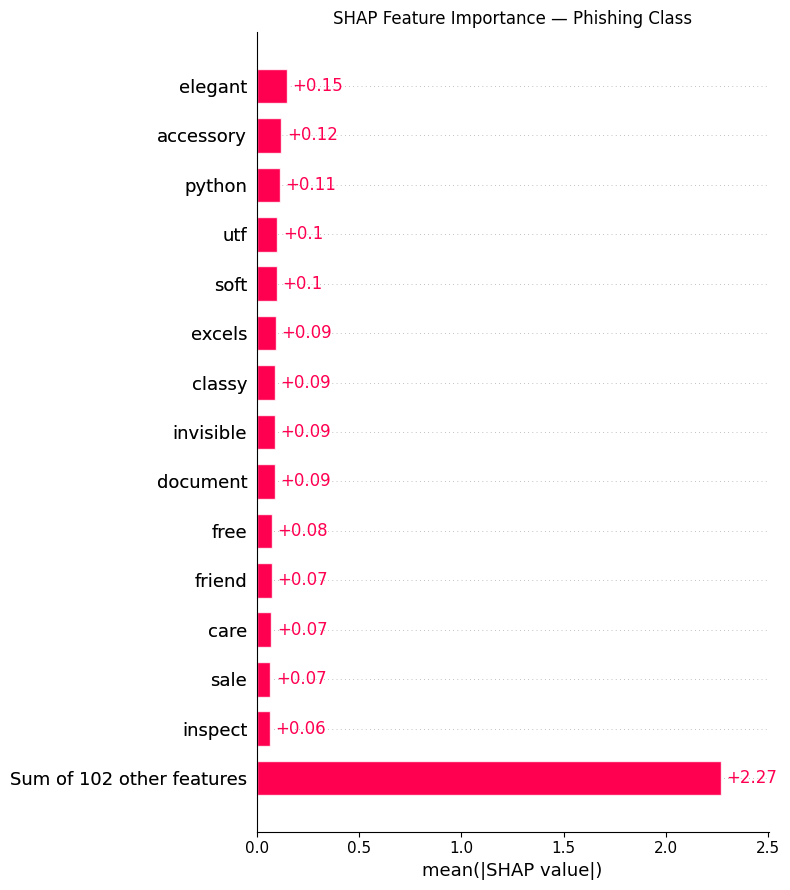

✅ SHAP plot saved!


In [ ]:
# Cell 9 - SHAP visualization
import matplotlib.pyplot as plt
import os

os.makedirs('/content/drive/MyDrive/PhishingDetector/plots', exist_ok=True)

# Plot SHAP for first phishing email
print('📊 SHAP explanation for sample emails:')

# Text plot for each sample
for i in range(3):
    label = 'Phishing' if y_test.iloc[i] == 1 else 'Legitimate'
    print(f'\nSample {i+1} — Actual: {label}')
    shap.plots.text(shap_values[i], display=True)

# Summary bar plot
plt.figure(figsize=(10, 4))
shap.plots.bar(shap_values[:, :, 1], max_display=15, show=False)
plt.title('SHAP Feature Importance — Phishing Class')
plt.tight_layout()
save_path = '/content/drive/MyDrive/PhishingDetector/plots/shap_summary.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print('✅ SHAP plot saved!')

📊 Explainability Summary:

🔴 Top PHISHING trigger words (LIME):
   classy               score: 0.0139
   accessory            score: 0.0105
   give                 score: 0.0087
   elegant              score: 0.0087
   gift                 score: 0.0082

🔵 Top LEGITIMATE trigger words (LIME):
   attached             score: -0.0629
   please               score: -0.0552
   happen               score: -0.0543
   brent                score: -0.0523
   schedule             score: -0.0478

✅ Summary saved!


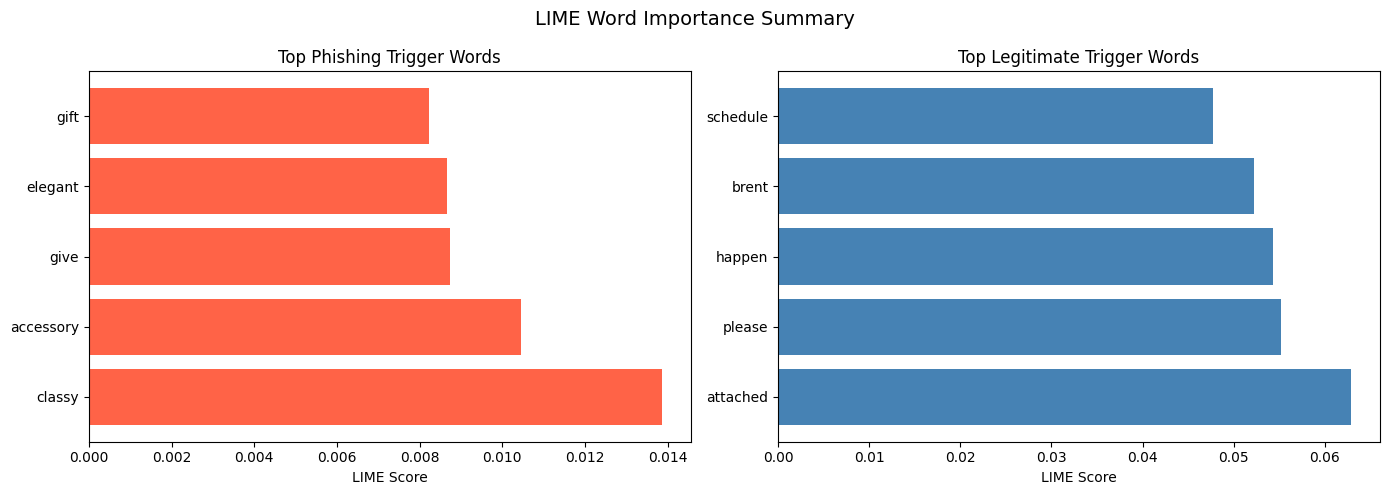

✅ Final plot saved!


In [ ]:
# Cell 10 - Save final explainability summary
import pandas as pd
import os

os.makedirs('/content/drive/MyDrive/PhishingDetector/plots', exist_ok=True)

# Save LIME + SHAP word importance summary
lime_words_phishing = dict(exp.as_list())
lime_words_legit = dict(exp_legit.as_list())

summary = {
    'LIME_Phishing_TopWords': sorted(lime_words_phishing.items(),
                                      key=lambda x: x[1], reverse=True)[:5],
    'LIME_Legit_TopWords': sorted(lime_words_legit.items(),
                                   key=lambda x: x[1])[:5]
}

print('📊 Explainability Summary:')
print('\n🔴 Top PHISHING trigger words (LIME):')
for word, score in summary['LIME_Phishing_TopWords']:
    print(f'   {word:20s} score: {score:.4f}')

print('\n🔵 Top LEGITIMATE trigger words (LIME):')
for word, score in summary['LIME_Legit_TopWords']:
    print(f'   {word:20s} score: {score:.4f}')

# Save summary to Drive
summary_df = pd.DataFrame({
    'word': [w for w,s in summary['LIME_Phishing_TopWords']] +
            [w for w,s in summary['LIME_Legit_TopWords']],
    'score': [s for w,s in summary['LIME_Phishing_TopWords']] +
             [s for w,s in summary['LIME_Legit_TopWords']],
    'type': ['Phishing']*5 + ['Legitimate']*5
})

save_path = '/content/drive/MyDrive/PhishingDetector/plots/explainability_summary.csv'
summary_df.to_csv(save_path, index=False)
print(f'\n✅ Summary saved!')

# Final combined plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Phishing words
phishing_words = [w for w,s in summary['LIME_Phishing_TopWords']]
phishing_scores = [s for w,s in summary['LIME_Phishing_TopWords']]
axes[0].barh(phishing_words, phishing_scores, color='tomato')
axes[0].set_title('Top Phishing Trigger Words')
axes[0].set_xlabel('LIME Score')

# Legit words
legit_words = [w for w,s in summary['LIME_Legit_TopWords']]
legit_scores = [abs(s) for w,s in summary['LIME_Legit_TopWords']]
axes[1].barh(legit_words, legit_scores, color='steelblue')
axes[1].set_title('Top Legitimate Trigger Words')
axes[1].set_xlabel('LIME Score')

plt.suptitle('LIME Word Importance Summary', fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PhishingDetector/plots/lime_summary.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Final plot saved!')